In [ ]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os
import sys

sys.path.append("../scr")
from ARIMA_tuning import sarimax_tuning
from ARIMA_CV import compare_sarimax_models

## Fetch Data

In [2]:
LAT, LON = 56.1629, 10.2039  # Aarhus
START, END = "2025-04-18", "2026-04-18"

# ── Historical air quality (NO2, O3, PM10, PM2.5) ─────────────────────────
print("Fetching air quality...")
aq = requests.get(
    "https://air-quality-api.open-meteo.com/v1/air-quality",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "nitrogen_dioxide,ozone,pm10,pm2_5",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

aq_df = pd.DataFrame({
    "Recorded": pd.to_datetime(aq["hourly"]["time"]),
    "NO2":      aq["hourly"]["nitrogen_dioxide"],
    "O3":       aq["hourly"]["ozone"],
    "PM10":     aq["hourly"]["pm10"],
    "PM2.5":    aq["hourly"]["pm2_5"],
})

# ── Historical weather (wind, temp, radiation, humidity) ──────────────────
print("Fetching weather...")
wx = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "wind_speed_10m,temperature_2m,shortwave_radiation,relative_humidity_2m",
        "wind_speed_unit": "ms",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

wx_df = pd.DataFrame({
    "Recorded":        pd.to_datetime(wx["hourly"]["time"]),
    "wind_speed":      wx["hourly"]["wind_speed_10m"],
    "temperature":     wx["hourly"]["temperature_2m"],
    "solar_radiation": wx["hourly"]["shortwave_radiation"],
    "humidity":        wx["hourly"]["relative_humidity_2m"],
})

# ── Merge ─────────────────────────────────────────────────────────────────
print("Merging...")
df = aq_df.merge(wx_df, on="Recorded", how="inner")
df = df.sort_values("Recorded").reset_index(drop=True)
df["Recorded"] = pd.to_datetime(df["Recorded"])
df = df.set_index("Recorded")

print(f"\nFinal shape: {df.shape}")
print(df.head())
print(f"\nDate range: {df.index.min()} → {df.index.max()}")
print(f"Missing values:\n{df.isnull().sum()}")

Fetching air quality...
Fetching weather...
Merging...

Final shape: (8784, 8)
                     NO2    O3  PM10  PM2.5  wind_speed  temperature  \
Recorded                                                               
2025-04-18 00:00:00  3.4  90.0   3.8    2.9        4.52          8.3   
2025-04-18 01:00:00  3.1  91.0   3.2    2.6        4.51          7.9   
2025-04-18 02:00:00  2.5  95.0   3.0    2.1        4.40          7.8   
2025-04-18 03:00:00  2.7  92.0   3.1    2.0        4.44          7.8   
2025-04-18 04:00:00  2.6  87.0   3.4    2.6        4.70          7.8   

                     solar_radiation  humidity  
Recorded                                        
2025-04-18 00:00:00              0.0        86  
2025-04-18 01:00:00              0.0        87  
2025-04-18 02:00:00              0.0        86  
2025-04-18 03:00:00              0.0        91  
2025-04-18 04:00:00              0.0        89  

Date range: 2025-04-18 00:00:00 → 2026-04-18 23:00:00
Missing values:
NO

## 2. Define combos and config

In [ ]:
combos = {
    "NO2": {
        "fit_1": set(),
        "fit_2": {"wind_speed"},
        "fit_3": {"temperature"},
        "fit_4": {"wind_speed", "temperature"},
        "fit_5": {"wind_speed", "temperature", "solar_radiation", "humidity"},
    },
    "O3": {
        "fit_1": set(),
        "fit_2": {"wind_speed"},
        "fit_3": {"temperature"},
        "fit_4": {"wind_speed", "temperature"},
        "fit_5": {"wind_speed", "temperature", "solar_radiation", "humidity"},
    },
    "PM2.5": {
        "fit_1": set(),
        "fit_2": {"temperature"},
        "fit_3": {"temperature", "humidity"}
    },
    "PM10": {
        "fit_1": set(),
        "fit_2": {"temperature"},
        "fit_3": {"temperature", "humidity"}
    },
}

HOLDOUT       = 96    # hours — hold out last 4 days
M             = 24    # seasonal period (hourly data)
ALL_EXOG_COLS = ["wind_speed", "temperature", "solar_radiation", "humidity"]

In [3]:
combos = {
    "PM2.5": {
        "fit_1": set(),
        "fit_2": {"temperature"},
        "fit_3": {"temperature", "humidity"},
        "fit_4": {"wind_speed", "temperature", "solar_radiation", "humidity"},
    },
    "PM10": {
        "fit_1": set(),
        "fit_2": {"temperature"},
        "fit_3": {"temperature", "humidity"},
        "fit_4": {"wind_speed", "temperature", "solar_radiation", "humidity"},
    },
}

HOLDOUT       = 96    # hours — hold out last 4 days
M             = 24    # seasonal period (hourly data)
ALL_EXOG_COLS = ["wind_speed", "temperature", "solar_radiation", "humidity"]

## 3. Run pipeline

For each pollutant:
1. Split target into train/test
2. Scale all exogenous features once
3. Loop fits — grid-search best SARIMA order per fit (returns spec dict)
4. Pass all specs to CV → selects single best model

In [4]:

for pollutant, fits in combos.items():
    print(f"POLLUTANT: {pollutant}")

    # Split target
    y = df[pollutant].values
    y_train, y_test = y[:-HOLDOUT], y[-HOLDOUT:]

    # Scale all exogenous features once — shared across all fits for this pollutant
    X_all             = df[ALL_EXOG_COLS].values
    scaler            = StandardScaler()
    X_train_scaled    = scaler.fit_transform(X_all[:-HOLDOUT])
    X_test_scaled     = scaler.transform(X_all[-HOLDOUT:])

    # Grid-search each fit, collect spec dicts
    specs = []
    for fit_name, predictor_set in fits.items():
        predictor_cols = sorted(predictor_set)
        fit_label      = f"{pollutant}_{fit_name}"
        print(f"\n {fit_label}  predictors={predictor_cols}")

        # Slice only the columns this fit uses from the already-scaled matrix
        if predictor_cols:
            col_idx    = [ALL_EXOG_COLS.index(c) for c in predictor_cols]
            X_tr_fit   = X_train_scaled[:, col_idx]
            X_te_fit   = X_test_scaled[:,  col_idx]
        else:
            X_tr_fit   = None
            X_te_fit   = None

        spec = sarimax_tuning(
            target_col     = pollutant,
            predictor_cols = predictor_cols,
            fit_name       = fit_label,
            y_train        = y_train,
            y_test         = y_test,
            X_train_scaled = X_tr_fit,
            X_test_scaled  = X_te_fit,
            m              = M,
        )
        specs.append(spec)

    # CV across all fits → best model for this pollutant
    print(f"\nCV comparison for {pollutant} ({len(specs)} fits)")
    compare_sarimax_models(
        pollutant          = pollutant,
        specs              = specs,
        y_train            = y_train,
        y_test             = y_test,
        X_train_scaled     = X_train_scaled,
        X_test_scaled      = X_test_scaled,
        all_predictor_cols = ALL_EXOG_COLS,
        m                  = M,
        forecast_horizon   = HOLDOUT,
        initial=len(y_train)-5*96,
    )


POLLUTANT: PM2.5

 PM2.5_fit_1  predictors=[]
  [PM2.5_fit_1] d=1, D=0
    SARIMA(0,1,1)(0,0,1)[24]  AIC=19160.35
    SARIMA(0,1,1)(1,0,1)[24]  AIC=19062.89
    SARIMA(0,1,2)(0,0,1)[24]  AIC=18938.43
    SARIMA(0,1,2)(1,0,1)[24]  AIC=18865.82
    SARIMA(0,1,3)(0,0,1)[24]  AIC=18896.29
    SARIMA(0,1,3)(1,0,1)[24]  AIC=18835.31
    SARIMA(1,1,1)(0,0,1)[24]  AIC=18918.84
    SARIMA(1,1,1)(1,0,1)[24]  AIC=18855.99
    SARIMA(1,1,2)(0,0,1)[24]  AIC=18907.43
    SARIMA(1,1,2)(1,0,1)[24]  AIC=18844.49
    SARIMA(1,1,3)(0,0,1)[24]  AIC=18796.48
    SARIMA(1,1,3)(1,0,1)[24]  AIC=18733.36
    SARIMA(2,1,1)(0,0,1)[24]  AIC=18918.06
    SARIMA(2,1,1)(1,0,1)[24]  AIC=18857.31
    SARIMA(2,1,2)(0,0,1)[24]  AIC=18718.31
    SARIMA(2,1,2)(1,0,1)[24]  AIC=18680.44
    SARIMA(2,1,3)(0,0,1)[24]  AIC=18718.90
    SARIMA(2,1,3)(1,0,1)[24]  AIC=18679.59
    SARIMA(3,1,1)(0,0,1)[24]  AIC=18717.48
    SARIMA(3,1,1)(1,0,1)[24]  AIC=18695.25
    SARIMA(3,1,2)(0,0,1)[24]  AIC=18719.60
    SARIMA(3,1,2)(1,0,1)[2

## 4. Summary

In [4]:
print(f"\n{'='*60}")
print("FINAL RESULTS")
print(f"{'='*60}")
for pollutant in combos.keys():
    summary = pd.read_csv(f"ARIMA_fits/holdout_summary_{pollutant}.csv").iloc[0]
    print(
        f"{pollutant:6s}  winner={summary['best_spec']:25s}  "
        f"order={summary['order']}  seasonal={summary['seasonal_order']}  "
        f"RMSE={summary['holdout_rmse']:.4f}  SMAPE={summary['holdout_smape']:.2f}%"
    )


FINAL RESULTS
NO2     winner=NO2_fit_2                  order=(3, 1, 1)  seasonal=(1, 1, 1, 24)  RMSE=6.1551  SMAPE=49.91%
O3      winner=O3_fit_2                   order=(2, 1, 2)  seasonal=(1, 1, 1, 24)  RMSE=16.0357  SMAPE=19.39%
PM2.5   winner=PM2.5_fit_1                order=(2, 1, 3)  seasonal=(1, 0, 1, 24)  RMSE=4.6855  SMAPE=24.56%
PM10    winner=PM10_fit_1                 order=(3, 1, 1)  seasonal=(1, 0, 1, 24)  RMSE=6.2145  SMAPE=30.02%


## 5. Holdout forecast plots and summary

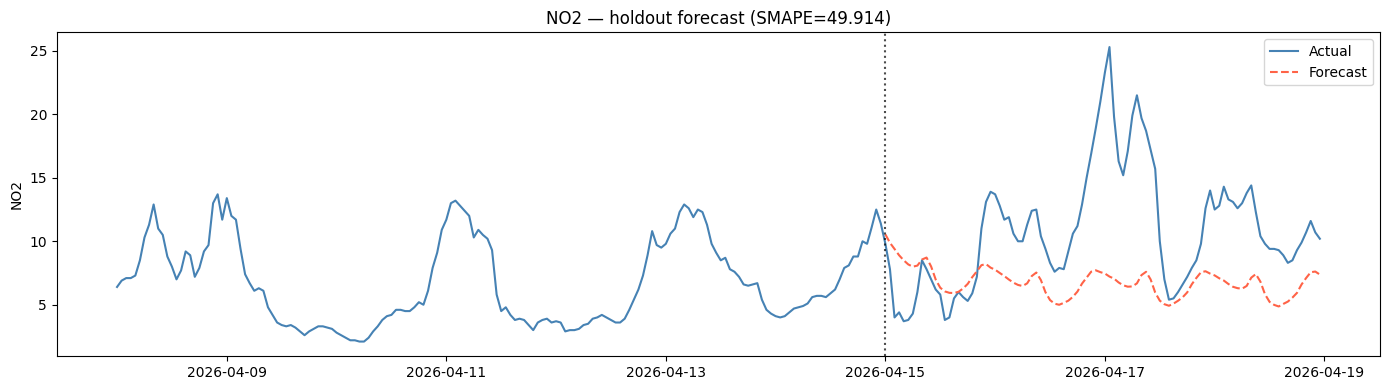

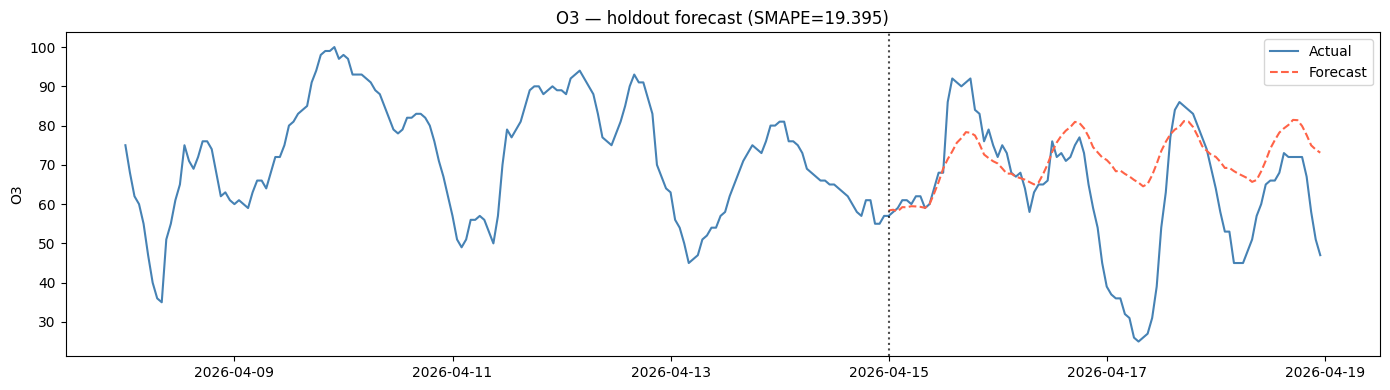

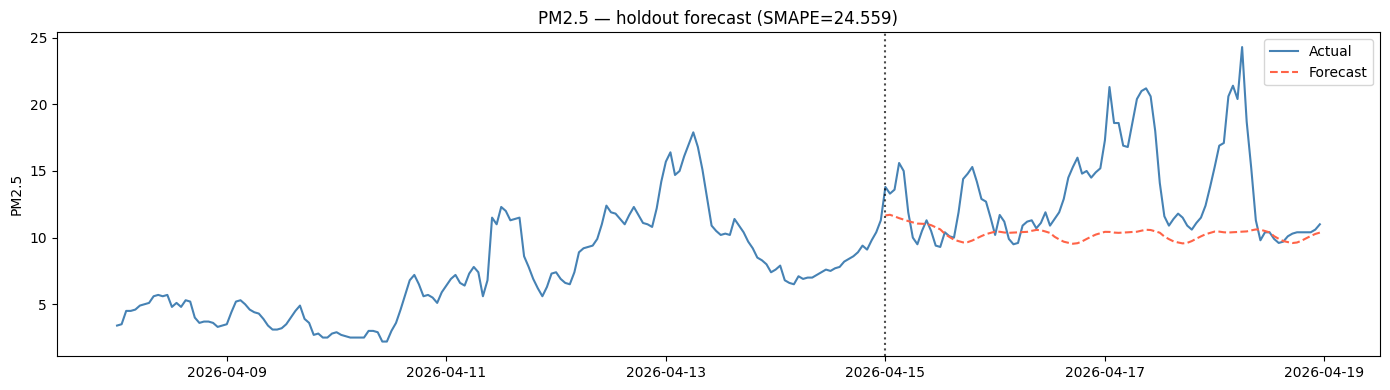

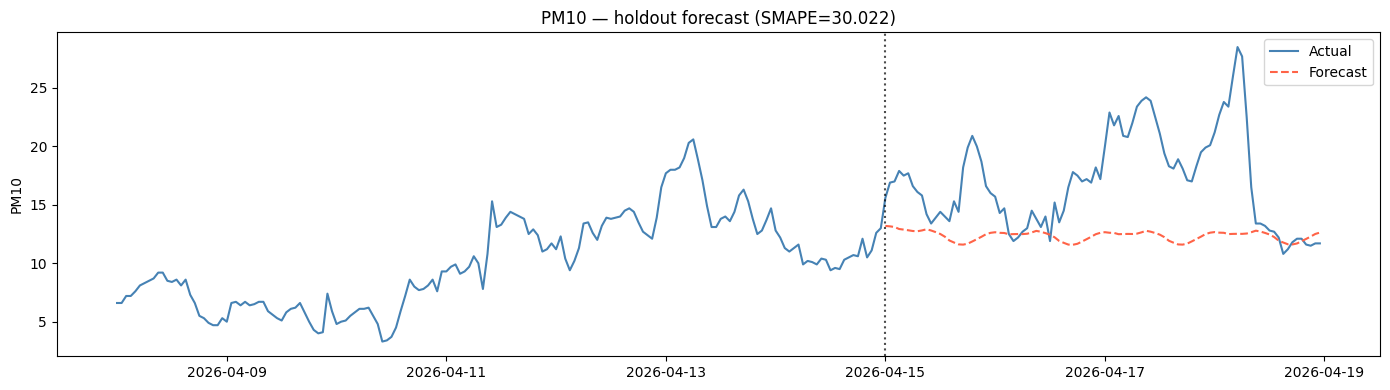

In [ ]:
prior_steps = 7 * 24  # hourly data

for pollutant in combos.keys():

    summary = pd.read_csv(
        f"ARIMA_fits/holdout_summary_{pollutant}.csv"
    ).iloc[0]

    forecast = pd.read_csv(
        f"ARIMA_fits/holdout_forecast_{pollutant}.csv"
    )

    t_test = df.index[-HOLDOUT:]
    t_actual = df.index[-(HOLDOUT + prior_steps):]

    actual_all = df.loc[t_actual, pollutant]

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(t_actual, actual_all,
            label="Actual",
            color="steelblue")

    ax.plot(t_test, forecast["forecast"],
            label="Forecast",
            color="tomato",
            linestyle="--")

    ax.axvline(t_test[0],
               color="black",
               linestyle=":",
               alpha=0.7)

    ax.set_title(
        f"{pollutant} — holdout forecast "
        f"(SMAPE={summary['holdout_smape']:.3f})"
    )

    ax.set_ylabel(pollutant)
    ax.legend()

    plt.tight_layout()

    os.makedirs("ARIMA_plots", exist_ok=True)

    plt.show()

In [ ]:

for pollutant in combos.keys():

    cv_results = pd.read_csv(
        f"ARIMA_fits/cv_results_{pollutant}.csv"
    )

    summary = pd.read_csv(
        f"ARIMA_fits/holdout_summary_{pollutant}.csv"
    ).iloc[0]
    
    best_model_files = glob.glob(f"ARIMA_fits/{pollutant}_BEST_{pollutant}_fit_*.pkl")
    best_model_path = best_model_files[0]
    best_model = joblib.load(best_model_path)
   
    print(cv_results)
    print(summary)
    print(best_model.summary())

      spec_name      order seasonal_order  \
0   PM2.5_fit_1  (2, 1, 3)  (1, 0, 1, 24)   
1   PM2.5_fit_1  (2, 1, 3)  (1, 0, 1, 24)   
2   PM2.5_fit_1  (2, 1, 3)  (1, 0, 1, 24)   
3   PM2.5_fit_1  (2, 1, 3)  (1, 0, 1, 24)   
4   PM2.5_fit_1  (2, 1, 3)  (1, 0, 1, 24)   
5   PM2.5_fit_2  (2, 1, 2)  (1, 0, 1, 24)   
6   PM2.5_fit_2  (2, 1, 2)  (1, 0, 1, 24)   
7   PM2.5_fit_2  (2, 1, 2)  (1, 0, 1, 24)   
8   PM2.5_fit_2  (2, 1, 2)  (1, 0, 1, 24)   
9   PM2.5_fit_2  (2, 1, 2)  (1, 0, 1, 24)   
10  PM2.5_fit_3  (2, 1, 2)  (1, 0, 1, 24)   
11  PM2.5_fit_3  (2, 1, 2)  (1, 0, 1, 24)   
12  PM2.5_fit_3  (2, 1, 2)  (1, 0, 1, 24)   
13  PM2.5_fit_3  (2, 1, 2)  (1, 0, 1, 24)   
14  PM2.5_fit_3  (2, 1, 2)  (1, 0, 1, 24)   
15  PM2.5_fit_4  (3, 1, 1)  (0, 0, 1, 24)   
16  PM2.5_fit_4  (3, 1, 1)  (0, 0, 1, 24)   
17  PM2.5_fit_4  (3, 1, 1)  (0, 0, 1, 24)   
18  PM2.5_fit_4  (3, 1, 1)  (0, 0, 1, 24)   
19  PM2.5_fit_4  (3, 1, 1)  (0, 0, 1, 24)   
20  PM2.5_fit_1  (2, 1, 3)  (1, 0, 1, 24)   
21  PM2.5_